<a href="https://colab.research.google.com/github/SukJinJang/Bigdata_computing/blob/main/20230585%EC%9E%A5%EC%84%9D%EC%A7%84_%EA%B8%B0%EB%A7%90%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ====================================================================
# [조건 1 & 조건 2] 데이터 준비, 50개 샘플링 및 파이프라인 3종 학습 및 저장
# ====================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 1. 데이터 로드 및 결측치 제거
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
df = pd.read_csv(url).dropna()  # 지정된 웹 경로에서 CSV 파일을 읽어온 후 결측값이 있는 모든 행을 즉시 제거

df.columns = df.columns.str.replace('_', ' ').str.strip().str.lower()  # 데이터셋 컬럼명 내부의 특수문자 및 공백을 정형화하여 접근 에러 방지

# 2. 특성 선택: 이제 소문자로만 안전하게 호출
features = ['adult mortality', 'bmi', 'gdp']  # 기대수명 예측을 위해 Schooling을 제외하고 자율 선택한 3개의 전처리 대상 독립변수 지정
X = df[features].values  # 입력 특성 데이터프레임을 넘파이 2차원 배열 형태로 추출
y = df['life expectancy'].values  # 예측 목표가 되는 기대수명 데이터를 넘파이 1차원 배열 형태로 추출

# 3. 데이터 분할 (Train 80% / Test 20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 전체 데이터를 8:2 비율의 훈련 및 테스트 세트로 분할

# 4. 과대적합 관찰을 위해 훈련 데이터 50개 샘플만 추출
np.random.seed(42)  # 결과의 일관성 및 재현성을 확보하기 위해 넘파이 난수 생성 시드 고정
sample_indices = np.random.choice(len(X_train_full), 50, replace=False)  # 전체 분할된 훈련 데이터 인덱스 중 중복 없이 무작위로 50개 선택
X_train = X_train_full[sample_indices]  # 추출된 50개의 무작위 인덱스를 적용하여 소규모 학습용 특성 데이터셋 구축
y_train = y_train_full[sample_indices]  # 추출된 50개의 무작위 인덱스를 적용하여 소규모 학습용 정답 레이블셋 구축

# 5. 파이프라인 기반 모델 3종 정의
models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),  # 데이터의 특성 스케일을 평균 0, 분산 1로 정규화하는 표준화 단계
        ("linear", LinearRegression())  # 전처리된 스케일을 바탕으로 최적의 선형 가중치를 찾는 1차 회귀 모델 단계
    ]),
    "Poly": Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),  # 규제 없는 오버피팅 유도를 위해 3차 가상 교차항 특성을 생성하는 단계
        ("scaler", StandardScaler()),  # 고차원 변환으로 인해 변동 폭이 커진 특성들의 스케일을 균일하게 맞추는 표준화 단계
        ("linear", LinearRegression())  # 복잡해진 3차 다항 특성을 바탕으로 가중치 규제 없이 완벽한 피팅을 시도하는 회귀 단계
    ]),
    "Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),  # Poly 모델과 동일하게 고차원의 3차 다항 변환을 수행하는 단계
        ("scaler", StandardScaler()),  # 다항 변환된 고차원 특성 가중치 연산의 안정성을 높이기 위한 스케일 표준화 단계
        ("ridge", Ridge(alpha=1.0))  # 계수 크기를 제한하는 L2 규제(alpha=1.0)를 적용하여 과대적합을 기하학적으로 제어하는 회귀 단계
    ])
}

# 6. 모델 학습 및 성능 지표 수집
trained_models = {}  # 학습이 완료된 3종의 파이프라인 모델 객체를 바인딩할 빈 딕셔너리 생성
performance_data = []  # 판다스 데이터프레임 변환을 위해 각 모델별 평가지표 딕셔너리를 모아둘 빈 리스트 정의

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)  # 추출한 50개의 소규모 훈련 데이터(X_train, y_train)를 가동하여 각 파이프라인 모델 순차 학습 진행
    trained_models[name] = pipeline  # 저장을 목적으로 학습 연산이 완료된 파이프라인 객체를 해당 모델명을 키값으로 등록

    y_train_pred = pipeline.predict(X_train)  # 현재 학습 완료된 파이프라인을 통과시켜 소규모 학습 데이터셋에 대한 기대수명 예측값 산출
    y_test_pred = pipeline.predict(X_test)  # 모델의 일반화 성능 검증을 위해 보지 못한 독립 테스트 데이터셋에 대한 예측값 산출

    train_r2 = r2_score(y_train, y_train_pred)  # 학습 데이터에 대한 예측 스코어와 실제 정답을 대조하여 결정계수(R^2 점수) 계산
    test_r2 = r2_score(y_test, y_test_pred)  # 테스트 데이터에 대한 예측 스코어와 실제 정답을 대조하여 일반화 결정계수(R^2 점수) 계산
    train_mse = mean_squared_error(y_train, y_train_pred)  # 학습 데이터의 실제 값과 예측 수치 사이의 평균제곱오차 오차 지표 산출
    test_mse = mean_squared_error(y_test, y_test_pred)  # 테스트 데이터의 실제 값과 예측 수치 사이의 평균제곱오차 오차 지표 산출

    if "poly" in pipeline.named_steps:
        complexity = pipeline.named_steps["poly"].n_output_features_  # 다항 변환이 적용된 모델의 경우 최종 생성 완료된 총 특성 복잡도 개수 추출
    else:
        complexity = X_train.shape[1]  # 다항 변환이 없는 기본 선형 모델의 경우 원본 독립변수의 개수(3개)를 특성 복잡도로 지정

    # 대시보드 화면상에 고정 테이블 형태로 상시 출력할 다중 성능 지표 성적표 데이터를 딕셔너리로 가공하여 추가
    performance_data.append({
        "Model": name,
        "Complexity": complexity,
        "Train R2": round(train_r2, 4),
        "Test R2": round(test_r2, 4),
        "Train MSE": round(train_mse, 4),
        "Test MSE": round(test_mse, 4)
    })

df_perf = pd.DataFrame(performance_data)  # 누적된 평가지표 데이터 리스트를 대시보드 st.dataframe 포맷에 적합한 판다스 데이터프레임으로 변환

# 7. 대시보드 구동용 범위 기준값 저장 (소문자 데이터 적용)
# 사용자가 Streamlit 웹 사이드바 슬라이더를 조절할 때 실제 데이터 범위를 벗어나지 않도록 특성별 통계 수치 리스트업
stats = {
    "am_min": float(df['adult mortality'].min()), "am_max": float(df['adult mortality'].max()), "am_mean": float(df['adult mortality'].mean()),
    "bmi_min": float(df['bmi'].min()), "bmi_max": float(df['bmi'].max()), "bmi_mean": float(df['bmi'].mean()),
    "gdp_min": float(df['gdp'].min()), "gdp_max": float(df['gdp'].max()), "gdp_mean": float(df['gdp'].mean()),
}

# 8. joblib으로 통합 저장
# 대시보드 웹 파일(app.py)에서 개별적인 연산 없이 언피클링 후 즉시 레이아웃에 뿌려줄 수 있도록 모든 메타데이터를 하나로 패키징
payload = {
    "models": trained_models,
    "df_perf": df_perf,
    "stats": stats
}

joblib.dump(payload, "life_expectancy_pipeline.pkl")  # 지정한 파일명("life_expectancy_pipeline.pkl")으로 가동 상태 그대로 바이너리 덤프 실행
print("✅ 1단계 성공: 파이프라인 모델 학습 및 life_expectancy_pipeline.pkl 저장 완료!")
print("\n[학습된 모델 성능 결과 요약]")
print(df_perf)

✅ 1단계 성공: 파이프라인 모델 학습 및 life_expectancy_pipeline.pkl 저장 완료!

[학습된 모델 성능 결과 요약]
    Model  Complexity  Train R2  Test R2  Train MSE  Test MSE
0  Linear           3    0.7289   0.5702    29.7286   30.5253
1    Poly          19    0.9008  -4.9030    10.8819  419.2477
2   Ridge          19    0.7991   0.5448    22.0343   32.3263


In [2]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# ====================================================================
# [조건 3 & 조건 4] 웹 서비스 구현 및 실시간 예측 UI 구성 (app.py)
# ====================================================================

# 1. 저장된 pkl 파일 로드
payload = joblib.load("life_expectancy_pipeline.pkl")  # 디스크에 저장되어 있는 최적화 파이프라인 패키지 데이터 로드
models = payload["models"]  # 딕셔너리에서 추출: 학습이 완료된 3종의 파이프라인 모델 객체들
df_perf = payload["df_perf"]  # 딕셔너리에서 추출: 3가지 모델의 종합 성능 평가지표 판다스 데이터프레임
stats = payload["stats"]  # 딕셔너리에서 추출: 입력 슬라이더 제한 범위를 조절하기 위한 소문자 특성 통계치

# 2. 대시보드 레이아웃 설정
st.set_page_config(page_title="기대수명 예측 시스템", layout="wide")  # 웹 브라우저의 페이지 제목 및 화면 해상도 와이드 모드 설정
st.title("🧬 다중 특성 회귀 파이프라인 기반 기대수명 예측 서비스")  # 웹 대시보드 최상단 메인 타이틀 텍스트 출력
st.markdown("WHO 데이터를 활용하여 고차원 다항 회귀의 과대적합을 분석하고 규제 효과를 검증합니다.")  # 대시보드 하위 명세 설명 기술

# 3. 사이드바 UI
st.sidebar.header("📋 신체 및 경제 지표 입력")  # 왼쪽 사이드바 영역에 입력 인터페이스 헤더 텍스트 출력
u_am = st.sidebar.slider("성인 사망률 (Adult Mortality)", stats["am_min"], stats["am_max"], stats["am_mean"])  # 실제 adult mortality 분포 범위를 활용한 슬라이더 생성
u_bmi = st.sidebar.slider("체질량지수 (BMI)", stats["bmi_min"], stats["bmi_max"], stats["bmi_mean"])  # 실제 bmi 분포 범위를 활용한 슬라이더 생성
u_gdp = st.sidebar.slider("국내총생산 (GDP)", stats["gdp_min"], stats["gdp_max"], stats["gdp_mean"])  # 실제 gdp 분포 범위를 활용한 슬라이더 생성

# 모델 선택 인터페이스
selected_model_name = st.sidebar.selectbox("예측에 사용할 파이프라인 모델 선택:", ["Linear", "Poly", "Ridge"])  # 사용자가 [Linear, Poly, Ridge] 중 하나를 선택할 드롭다운 생성
current_pipeline = models[selected_model_name]  # 사용자가 선택한 모델명 키값에 매칭되는 학습 완료 파이프라인 모델 추출

# 4. 메인 화면 - 성능 비교 섹션 구현
st.subheader("📊 1단계: 모델별 성능 지표 비교 (Linear vs Poly vs Ridge)")  # 메인 본문 영역 성능 지표 비교 섹션 서브 헤더 출력

# (1) 테이블 출력
st.write("### 📈 모델 평가 지표 테이블 (R² 및 MSE)")  # 평가지표 테이블 타이틀 명시
st.dataframe(df_perf.set_index("Model"), use_container_width=True)  # 'Model' 컬럼을 인덱스로 잡고 웹 화면 너비에 맞게 전체 성능 비교 테이블 상시 출력

# (2) 막대그래프 시각화
col1, col2 = st.columns([2, 1])  # 시각화 그래프와 리포트 영역을 깔끔하게 분할하기 위한 가로 2:1 비율 레이아웃 컬럼 생성
with col1:
    st.write("### 📉 모델별 예측 성능 (Test R² Score) 비교")  # 1번 컬럼 내부에 막대그래프 타이틀 명시
    fig, ax = plt.subplots(figsize=(7, 3.5))  # matplotlib을 이용해 시각화 차트를 그리기 위한 도화지 및 축 객체 생성

    colors = ['dodgerblue' if x == 'Linear' else 'red' if x == 'Poly' else 'green' for x in df_perf['Model']]  # 모델명 조건에 따라 블루, 레드, 그린 순서로 다른 막대 색상 리스트 정의
    bars = ax.bar(df_perf['Model'], df_perf['Test R2'], color=colors, width=0.5, edgecolor='black')  # x축 모델명, y축 Test R2 스코어를 기반으로 한 막대그래프 렌더링

    ax.set_ylabel("Test R2 Score", fontsize=10)  # y축 세로 레이블 명칭 및 폰트 크기 지정
    ax.set_title("Model Comparison: Higher is Better", fontsize=11, fontweight='bold')  # 그래프 최상단 세부 타이틀 서식 조정

    # 그래프 y축 범위를 동적으로 잡아줌 (과대적합 시 마이너스로 떨어지는 것 방어)
    min_test_r2 = df_perf['Test R2'].min()  # 오버피팅으로 극단적으로 깎인 Test R2의 최소 점수를 탐색
    ax.set_ylim(min_test_r2 - 0.2 if min_test_r2 < 0 else 0, 1.1)  # 마이너스 값 존재 유무에 따라 상하한 스케일을 유연하게 보정
    ax.grid(True, linestyle=':', alpha=0.6)  # 시각적 가독성 확보를 위해 배경에 흐릿한 격자 점선 추가

    for bar in bars:
        height = bar.get_height()  # 개별 막대의 세로 높이(Test R2 점수 데이터값)를 추출
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3 if height >= 0 else -10),
                    textcoords="offset points",
                    ha='center', va='bottom' if height >= 0 else 'top', fontsize=9, fontweight='bold')  # 각 막대의 상단 혹은 하단 경계면에 텍스트 점수 라벨 출력

    st.pyplot(fig)  # 생성 및 스타일 처리가 완료된 matplotlib 차트 피겨 객체를 streamlit 웹 대시보드에 렌더링

with col2:
    st.write("### 💡 규제 모델 분석 리포트")  # 2번 컬럼 내부에 리포트 섹션 타이틀 명시
    poly_complex = df_perf.loc[df_perf['Model'] == 'Poly', 'Complexity'].values[0]  # 성적표 데이터프레임 내부에서 Poly 모델이 갖는 특성 복잡도 개수 추출
    ridge_test_r2 = df_perf.loc[df_perf['Model'] == 'Ridge', 'Test R2'].values[0]  # 성적표 데이터프레임 내부에서 Ridge 모델의 최종 일반화 Test R2 점수 추출

    st.info(f"독립변수 3개가 3차 다항식으로 변환되며 **{poly_complex}개**의 복합 특성으로 확장되었습니다.\n\n"
            f"**Ridge 규제 모델**은 계수 크기를 제어하여 **Test R²: {ridge_test_r2:.4f}**의 일반화를 이뤄냅니다.")  # 동적으로 가공된 분석 메시지를 정보성 상자(st.info) 형태로 고정 출력

# 5. 실시간 예측 결과 출력
st.divider()  # 상단 평가지표 분석 영역과 하단 실시간 동적 예측 구역을 나누는 세련된 수평 구분선 배치
st.subheader("🎯 2단계: 선택된 모델의 실시간 기대수명 진단 결과")  # 2단계 동적 예측 영역 서브 헤더 출력

new_data = np.array([[u_am, u_bmi, u_gdp]])  # 사이드바 슬라이더를 통해 사용자가 지정한 3개 변수 입력 값을 scikit-learn 규격인 2차원 배열로 전환
prediction = current_pipeline.predict(new_data)  # 선택된 모델 파이프라인의 스케일러 및 다항변환 단계를 거쳐 실시간 최종 예측 결과 산출

st.metric(label=f"🏃‍♂️ 현재 {selected_model_name} 모델 기반 예측치", value=f"{prediction[0]:.2f} 세")  # 최종 수명 예측 결과 값을 대시보드 중앙에 실시간 크고 아름다운 글씨 지표로 출력

Writing app.py


In [3]:
# ====================================================================
# [조건 5] ngrok 터널링을 통한 공인 웹 서비스 배포 (4단계)
# ====================================================================
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os
import time

ngrok.kill()  # 백그라운드에 남아있을 수 있는 기존 ngrok 터널 프로세스를 강제 종료하여 충돌 방지
ngrok.set_auth_token("3Dw22YMOEqeXn10XxuBDRmp6tdh_2aucYft9tCYsLVy87HzF9")  # 보안 및 장시간 세션 유지를 위해 제공된 ngrok 개인 고유 인증 토큰 설정

os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")  # 터미널을 꺼도 유지되도록 로그 출력을 숨긴 채 로컬호스트 8501 포트로 대시보드 백그라운드 구동
time.sleep(3)  # Streamlit 웹 서버 엔진이 메모리에 안전하게 부팅 및 안착할 때까지 3초간 대기

public_url = ngrok.connect(8501, bind_tls=True)  # SSL 보안 프로토콜(HTTPS)을 강제 적용하여 로컬 8501 포트를 외부 공인 도메인 주소로 포워딩 연동

print("=" * 70)
print("🎉 과제 성공: Streamlit 공인 웹 서비스 배포가 성공적으로 완료되었습니다!")
print(f"👉 아래 생성된 퍼블릭 주소 링크를 클릭하여 대시보드에 접속하세요:\n{public_url}")  # 사용자가 마우스로 클릭하여 웹 사이트에 접속할 수 있도록 최종 생성된 보안 퍼블릭 URL 주소 출력
print("=" * 70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 107.6 MB/s eta 0:00:00
🎉 과제 성공: Streamlit 공인 웹 서비스 배포가 성공적으로 완료되었습니다!
👉 아래 생성된 퍼블릭 주소 링크를 클릭하여 대시보드에 접속하세요:
NgrokTunnel: "https://ecologist-unlighted-scuttle.ngrok-free.dev" -> "http://localhost:8501"


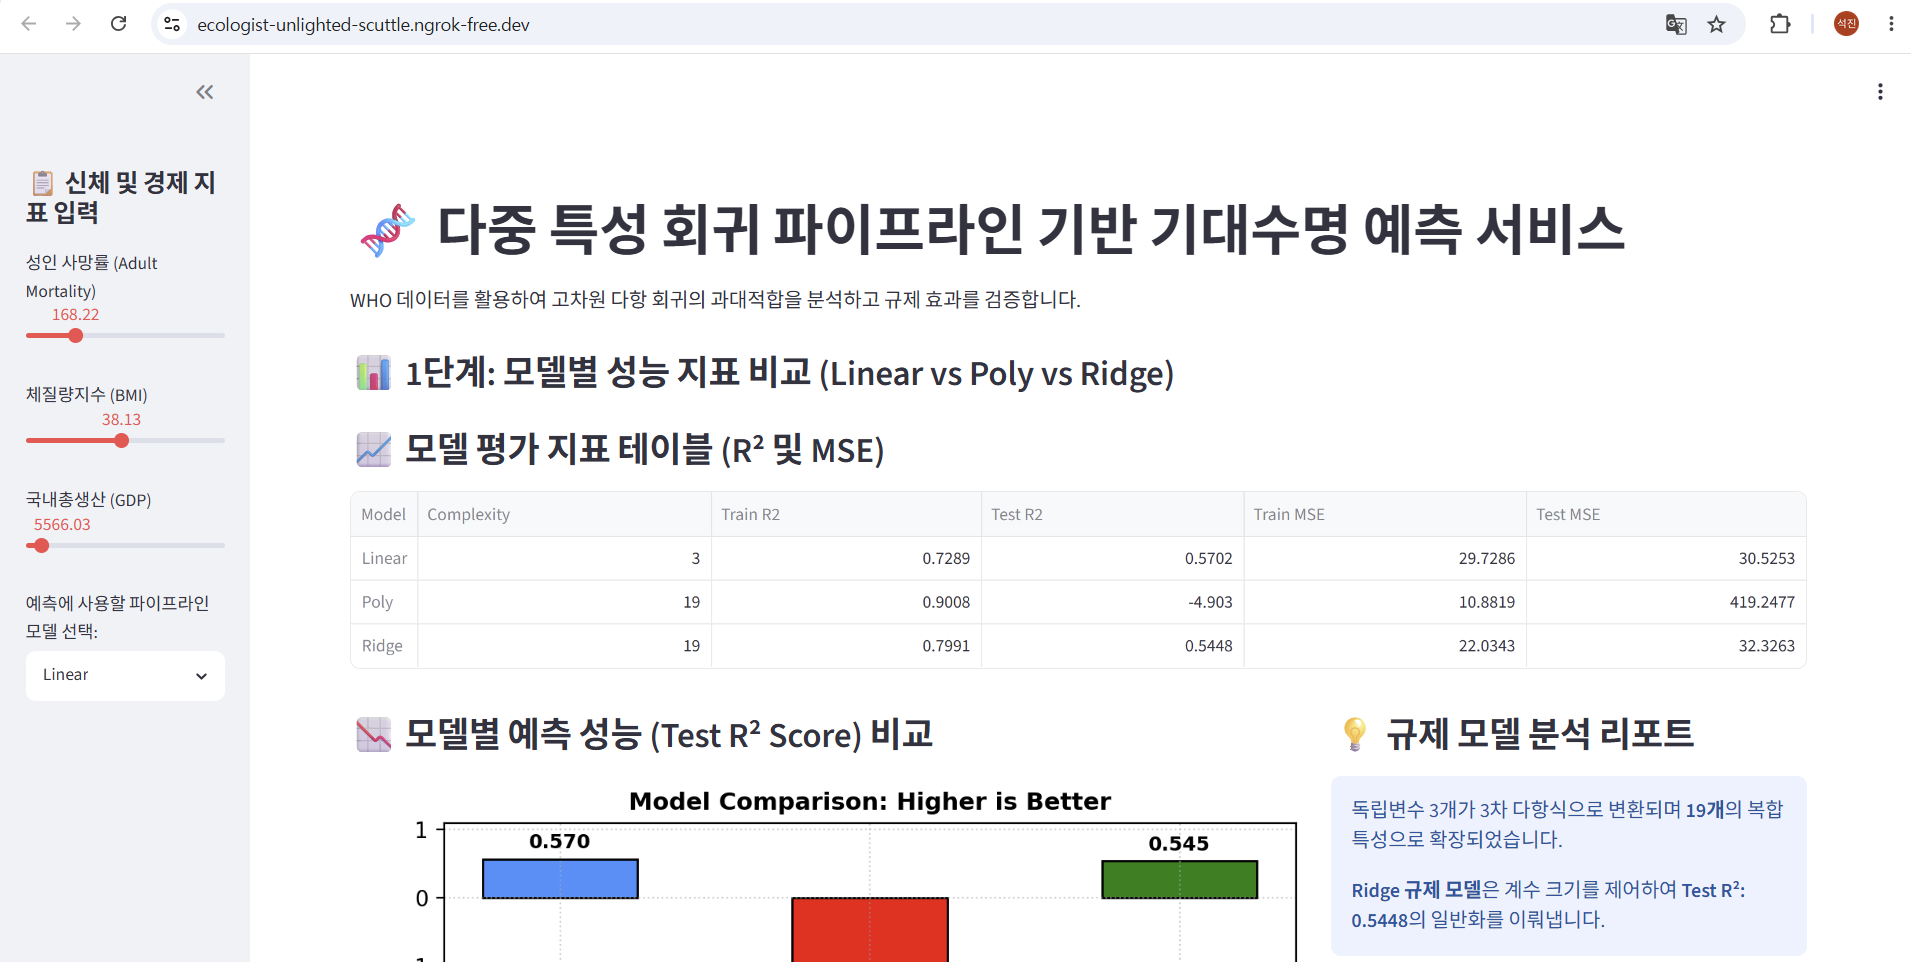
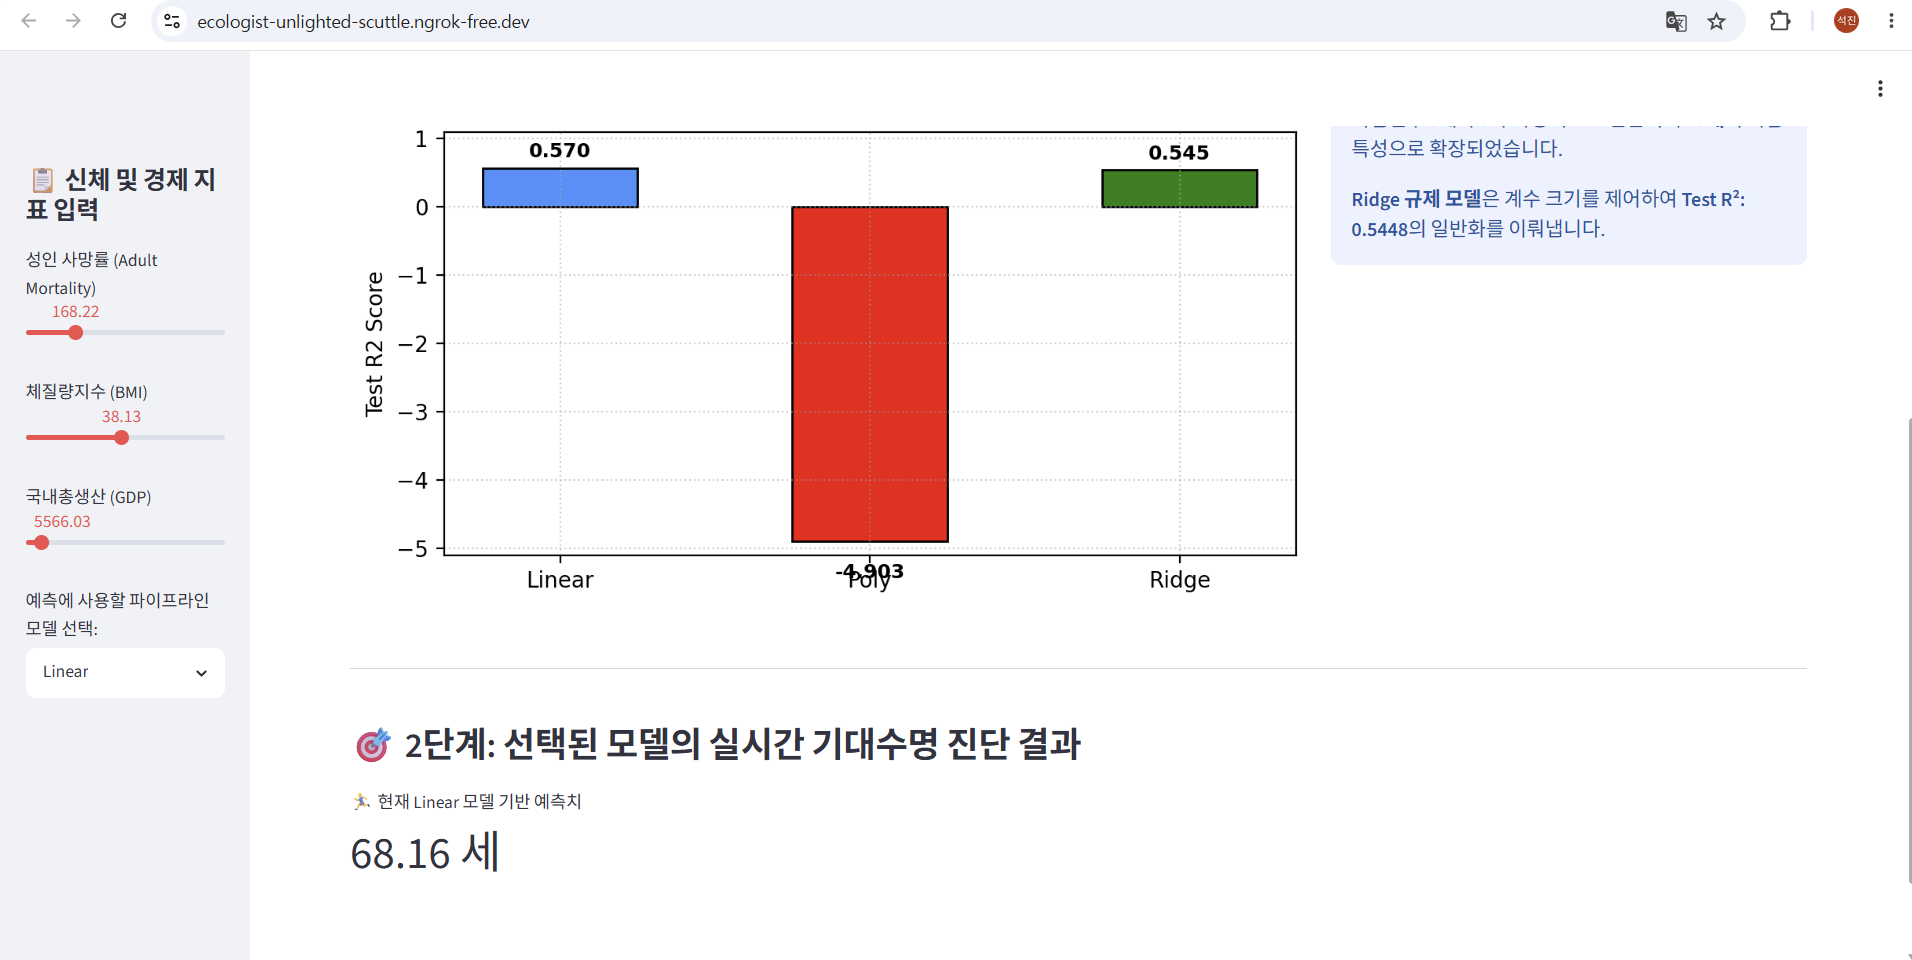

/content/app.py

